# Projeto: Segmentação de Clientes e Redução de Dimensionalidade (Customer Personality Analysis)

## 1. O Problema de Negócio

Uma empresa de e-commerce possui um banco de dados rico com dezenas de atributos sobre os clientes (comportamento de compra, histórico de navegação, gastos por categoria, dados demográficos e respostas a campanhas).

*  Desafio: A alta quantidade de variáveis (alta dimensionalidade) gera ruído e multicolinearidade, dificultando o agrupamento (clustering) de clientes para campanhas personalizadas.

*  Objetivo: Utilizar o PCA para reduzir o espaço de atributos mantendo a maior parte da variância explicada, e em seguida aplicar um algoritmo de agrupamento (como K-Means) para definir personas de clientes e sugerir ações de marketing.


### 2. O Roteiro do Projeto (Roadmap)

O projeto esta dividido em 5 etapas principais:

1. Entendimento e Limpeza dos Dados (EDA):

* Análise exploratória, tratamento de missing values, outliers e encodificação de variáveis categóricas.
  

2. Pré-processamento e Padronização:

* Aplicação do StandardScaler (fundamental para o PCA, pois ele é sensível à escala das variáveis).
  

3. Aplicação do PCA:

* Cálculo da Matriz de Covariância, Autovalores e Autovetores.

* Análise da Scree Plot e da Variância Explicada Acumulada para definir o número ideal de componentes principais.

* Análise das Cargas Fatoriais (Loadings) para entender o que cada componente está capturando.

  

4. Modelagem (Clustering com K-Means):

* Aplicação do K-Means no espaço reduzido (componentes principais) vs. espaço original para comparar performance e tempo de processamento.
* Método do Cotovelo (Elbow Method) e Silhouette Score.

5. Storytelling e Recomendações de Negócio:

* Tradução dos clusters em personas reais de clientes.

* Conclusão sobre o impacto do PCA no resultado final.

  

In [ ]:
pip install -q -r requirements.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
# Mapeamento para renomear colunas para o Português
traducao_colunas = {
    'Income': 'Renda',
    'Kidhome': 'Criancas_Casa',
    'Teenhome': 'Adolescentes_Casa',
    'Recency': 'Recencia_Dias',
    'MntWines': 'Gasto_Vinhos',
    'MntFruits': 'Gasto_Frutas',
    'MntMeatProducts': 'Gasto_Carnes',
    'MntFishProducts': 'Gasto_Peixes',
    'MntSweetProducts': 'Gasto_Doces',
    'MntGoldProds': 'Gasto_Ouro',
    'NumDealsPurchases': 'Compras_Com_Desconto',
    'NumWebPurchases': 'Compras_Site',
    'NumCatalogPurchases': 'Compras_Catalogo',
    'NumStorePurchases': 'Compras_Loja_Fisica',
    'NumWebVisitsMonth': 'Visitas_Site_Mes',
    'AcceptedCmp1': 'Aceitou_Campanha_1',
    'AcceptedCmp2': 'Aceitou_Campanha_2',
    'AcceptedCmp3': 'Aceitou_Campanha_3',
    'AcceptedCmp4': 'Aceitou_Campanha_4',
    'AcceptedCmp5': 'Aceitou_Campanha_5',
    'Complain': 'Reclamacao_Ultimos_2Anos',
    'Response': 'Aceitou_Ultima_Campanha',
    'Education': 'Escolaridade',
    'Marital_Status': 'Estado_Civil'
}

df = df.rename(columns=traducao_colunas)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2240 non-null   int64  
 1   Year_Birth                2240 non-null   int64  
 2   Escolaridade              2240 non-null   str    
 3   Estado_Civil              2240 non-null   str    
 4   Renda                     2216 non-null   float64
 5   Criancas_Casa             2240 non-null   int64  
 6   Adolescentes_Casa         2240 non-null   int64  
 7   Dt_Customer               2240 non-null   str    
 8   Recencia_Dias             2240 non-null   int64  
 9   Gasto_Vinhos              2240 non-null   int64  
 10  Gasto_Frutas              2240 non-null   int64  
 11  Gasto_Carnes              2240 non-null   int64  
 12  Gasto_Peixes              2240 non-null   int64  
 13  Gasto_Doces               2240 non-null   int64  
 14  Gasto_Ouro         

In [8]:
# 1. Tratamento de Valores Nulos na coluna Income (Imputação pela mediana)
df['Renda'] = df['Renda'].fillna(df['Renda'].median())

# 2. Remoção de Colunas Irrelevantes ou sem Variância
# 'ID' é apenas identificador; Z_CostContact e Z_Revenue são constantes
remover_colunas = ['ID', 'Z_CostContact', 'Z_Revenue']
df_limpo = df.drop(columns=remover_colunas)

# 3. Engenharia de Recursos (Feature Engineering)
# Criar Idade a partir de Year_Birth (considerando o ano de coleta do dataset: 2014)
df_limpo['Idade'] = 2014 - df_limpo['Year_Birth']

# Criar Idade da Conta (Customer_Days) em dias a partir da data de cadastro
df_limpo['Dt_Customer'] = pd.to_datetime(df_limpo['Dt_Customer'], format='%d-%m-%Y')
max_date = df_limpo['Dt_Customer'].max()
df_limpo['Idade_conta'] = (max_date - df_limpo['Dt_Customer']).dt.days

# Criar Total de Gastos (Total_Spent) somando os produtos
df_limpo['Total_Gastos'] = (df_limpo['Gasto_Vinhos'] + df_limpo['Gasto_Frutas'] + 
                          df_limpo['Gasto_Carnes'] + df_limpo['Gasto_Peixes'] + 
                          df_limpo['Gasto_Doces'] + df_limpo['Gasto_Ouro'])

# Criar Total de Filhos (Children)
df_limpo['Total_Filhos'] = df_limpo['Criancas_Casa'] + df_limpo['Adolescentes_Casa']

# Criar Total de Compras (Total_Purchases)
df_limpo['Total_Compras'] = (df_limpo['Compras_Site'] + df_limpo['Compras_Catalogo'] + 
                               df_limpo['Compras_Loja_Fisica'] + df_limpo['Compras_Com_Desconto'])

# 4. Tratamento de Outliers (Fundamental para o PCA)
# Removendo idades anômalas (ex: acima de 90 anos) e renda extremamente fora do padrão
df_limpo = df_limpo[df_limpo['Idade'] < 90]
df_limpo = df_limpo[df_limpo['Renda'] < 600000]

# Removendo colunas originais que foram resumidas nas novas features
df_limpo = df_limpo.drop(columns=['Year_Birth', 'Dt_Customer'])

In [9]:
df_limpo.head()

,Escolaridade,Estado_Civil,Renda,Criancas_Casa,Adolescentes_Casa,Recencia_Dias,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,...,Aceitou_Campanha_5,Aceitou_Campanha_1,Aceitou_Campanha_2,Reclamacao_Ultimos_2Anos,Aceitou_Ultima_Campanha,Idade,Idade_conta,Total_Gastos,Total_Filhos,Total_Compras
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,57,663,1617,0,25
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,60,113,27,2,6
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,49,312,776,0,21
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,30,139,53,1,8
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,33,161,422,1,19


In [10]:
# 1. One-Hot Encoding para converter texto em valores 0 e 1
df_encoded = pd.get_dummies(df_limpo, columns=['Escolaridade', 'Estado_Civil'], drop_first=True)

print("Formato do dataset pronto para o PCA:", df_encoded.shape)

# 2. Padronização dos dados com StandardScaler (Média = 0, Desvio Padrão = 1)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

Formato do dataset pronto para o PCA: (2236, 38)


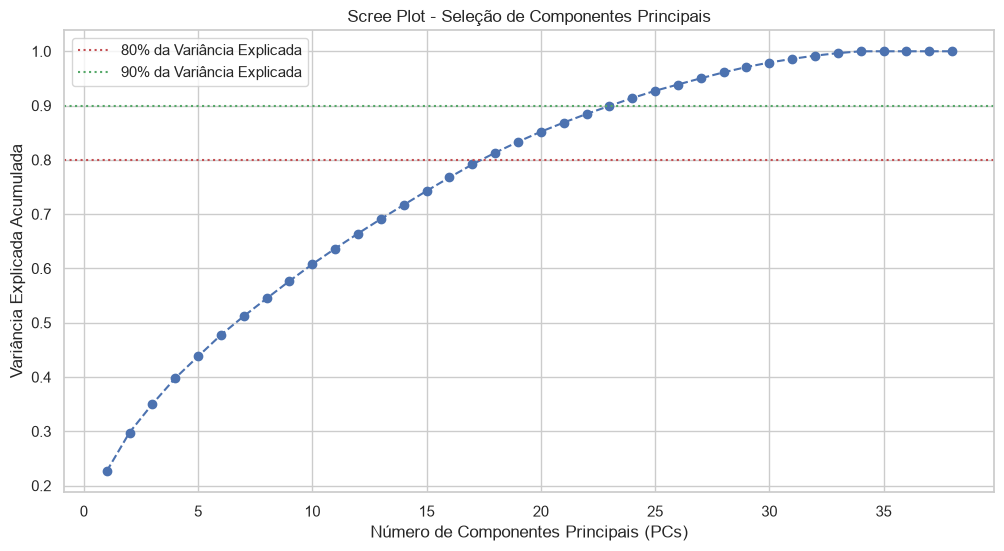

Variância explicada pela PC1: 22.64%
Variância explicada pela PC2: 7.14%
Variância acumulada pelas 2 primeiras PCs: 29.78%


In [11]:
# 1. Instanciar e ajustar o PCA nativo do Scikit-Learn
pca = PCA()
pca.fit(X_scaled)

# 2. Calcular a variância explicada e a variância acumulada
variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

# 3. Gerar o Scree Plot para o seu Dataset
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', linestyle='--', color='b')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% da Variância Explicada')
plt.axhline(y=0.90, color='g', linestyle=':', label='90% da Variância Explicada')
plt.xlabel('Número de Componentes Principais (PCs)')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Scree Plot - Seleção de Componentes Principais')
plt.legend()
plt.grid(True)
plt.show()

# Exibir percentual de variância capturado pelas primeiras componentes
print(f"Variância explicada pela PC1: {variancia_explicada[0]*100:.2f}%")
print(f"Variância explicada pela PC2: {variancia_explicada[1]*100:.2f}%")
print(f"Variância acumulada pelas 2 primeiras PCs: {(variancia_explicada[0] + variancia_explicada[1])*100:.2f}%")

In [12]:
# 1. Ajustar o PCA final com 18 componentes (preservando 80% de variância)
pca_80 = PCA(n_components=18)
X_pca_18 = pca_80.fit_transform(X_scaled)

# 2. Ajustar o PCA com 2 componentes para visualização 2D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# Criar um DataFrame para facilitar o plot 2D
df_pca_2d = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])

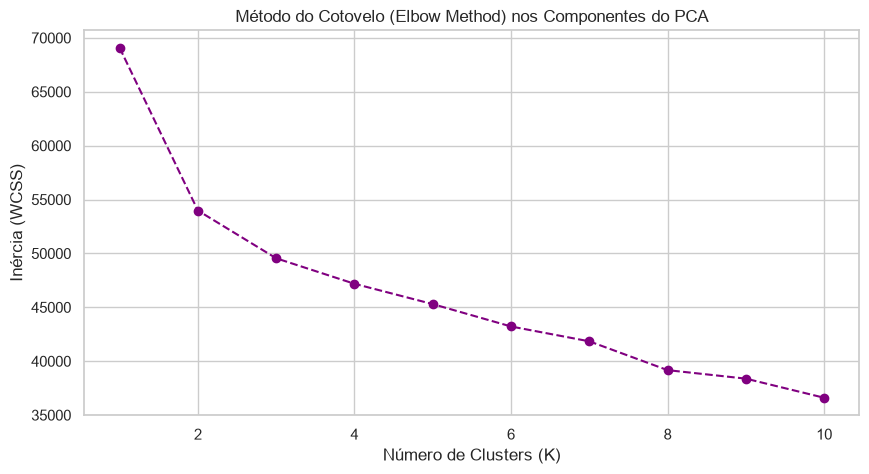

In [13]:
from sklearn.cluster import KMeans

# Método do Cotovelo para encontrar o número ideal de K (Clusters)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_18)
    wcss.append(kmeans.inertia_)

# Gráfico do Método do Cotovelo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo (Elbow Method) nos Componentes do PCA')
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

# Testando o Silhouette Score para diferentes valores de K
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_18)
    score = silhouette_score(X_pca_18, labels)
    print(f"Silhouette Score para K={k}: {score:.4f}")

Silhouette Score para K=2: 0.2274
Silhouette Score para K=3: 0.1682
Silhouette Score para K=4: 0.1599
Silhouette Score para K=5: 0.1063
Silhouette Score para K=6: 0.1120


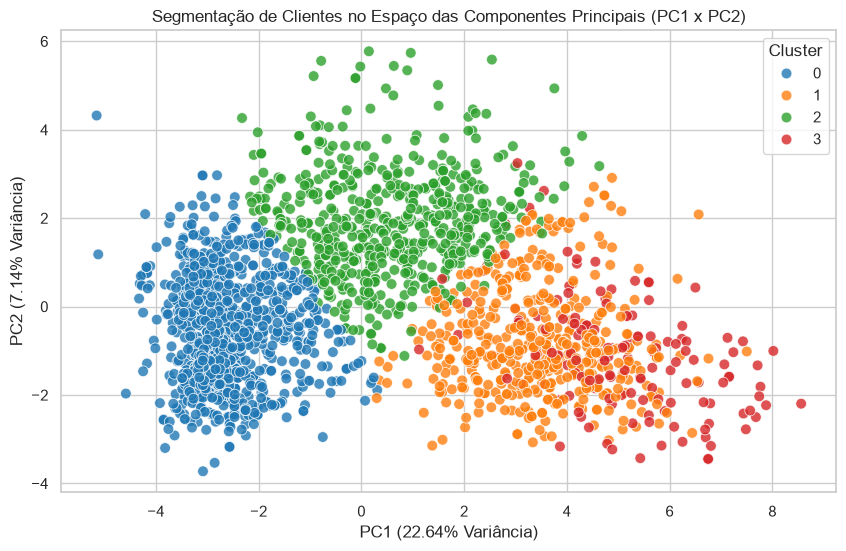

In [15]:
# 1. Ajustar o K-Means final com K=4 no espaço de 18 componentes
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_limpo['Cluster'] = kmeans_final.fit_predict(X_pca_18)

# 2. Atribuir coordenadas 2D para visualização
df_limpo['PC1'] = X_pca_2[:, 0]
df_limpo['PC2'] = X_pca_2[:, 1]

# 3. Plot Gráfico de Dispersão dos Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_limpo, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='tab10', 
    alpha=0.8, 
    s=60
)
plt.title('Segmentação de Clientes no Espaço das Componentes Principais (PC1 x PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variância)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [16]:
# Média do comportamento financeiro e demográfico por Cluster
perfil_clusters = df_limpo.groupby('Cluster')[[
    'Renda', 
    'Total_Gastos', 
    'Total_Compras', 
    'Idade', 
    'Total_Filhos', 
    'Recencia_Dias',
    'Visitas_Site_Mes'
]].mean().round(2)

# Adicionar contagem de clientes por cluster
perfil_clusters['Qtd_Clientes'] = df_limpo['Cluster'].value_counts()

display(perfil_clusters)

,Renda,Total_Gastos,Total_Compras,Idade,Total_Filhos,Recencia_Dias,Visitas_Site_Mes,Qtd_Clientes
Cluster,,,,,,,,
0,35019.27,94.95,7.79,42.32,1.23,49.54,6.42,1026
1,73160.66,1264.01,20.74,46.07,0.24,51.21,2.83,471
2,57124.74,712.55,21.01,49.51,1.23,47.71,5.91,592
3,81358.91,1635.31,20.83,43.70,0.17,45.07,3.26,147
